# 05_统计检验方法-正态性检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家介绍统计检验方法中的正态性检验\~

**正态性检验**是统计学中用来检查数据是否符合“正态分布”的一种方法。

我们知道，很多统计分析方法是基于数据符合正态分布的假设进行的。那正态分布是什么呢？

简而言之，**正态分布**是一种特定的概率分布，它的形状像一个“钟形曲线”。

比如，大家身高、体重、考试成绩等常见的变量，往往会呈现出类似的“钟形分布”。这意味着大部分数据集中在中间，少部分数据在两边。

#### 那正态性检验要干嘛呢？

在做统计分析之前，我们需要验证数据是不是符合正态分布。因为很多统计方法（比如t检验、ANOVA分析）都是假设数据符合正态分布的。如果数据不符合正态分布，可能这些方法的结论就不可靠了。所以，正态性检验就是用来帮助我们判断数据是不是“钟形曲线”的。

#### 常见的正态性检验方法：

1. **图形法**：用图来看数据是不是正态分布。最常见的是**QQ图**（Quantile-Quantile图），它会把数据的分位数和正态分布的分位数进行比较。如果点大致落在一条直线上，那么数据很可能是正态分布的。
2. **Shapiro-Wilk检验**：这是一种比较常见的统计检验方法，它给出一个p值。如果p值大于某个显著性水平（比如0.05），那么就认为数据符合正态分布；如果p值小于0.05，那么数据就不符合正态分布。
3. **Kolmogorov-Smirnov检验**：这是另一种检验正态性的方法，也通过计算数据和正态分布的差异来判断。

正态性检验就是为了检查数据是不是符合“钟形分布”，这很重要，因为很多统计方法的有效性依赖于数据是否正态分布。如果数据不正态，可能需要采用其他的统计方法或者对数据进行转化。

## 原理详解

### 1. 正态性检验的数学原理

正态性检验的主要目的是检验给定数据集是否来自一个正态分布。

为此，我们需要通过统计学方法计算出某些统计量，进而判断数据是否显著偏离正态分布。

通常，正态分布的概率密度函数（PDF）为：


$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)
$$


其中：

- $\mu$ 是正态分布的均值（mean），
- $\sigma$ 是正态分布的标准差（standard deviation）。

### 2. 常见的正态性检验方法及其原理

#### 1. Shapiro-Wilk检验

**Shapiro-Wilk检验**是一种基于样本数据和理论正态分布之间差异的检验方法，它的基本原理是通过计算一个统计量 $W$，来评估数据是否符合正态分布。

##### 公式推导：

假设有一组观测数据 $x_1, x_2, \dots, x_n$，我们首先对这些数据进行排序，得到 $x_{(1)}, x_{(2)}, \dots, x_{(n)}$，其中 $x_{(1)}$是最小值，$x_{(n)}$是最大值。

接着，我们计算样本数据的均值 $\bar{x}$和标准差 $s$。

Shapiro-Wilk统计量 $W$计算公式如下：


$$
W = \frac{\left( \sum_{i=1}^{n} a_i x_{(i)} \right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$


其中， $a_i$是基于样本大小和正态分布理论的常数，它的值来自于一个已知的表格。$x_{(i)}$是排序后的数据，$x_i$是原始数据。

- 如果 $W$值接近于1，那么说明数据大致符合正态分布。
- 如果 $W$值显著小于1（例如低于某个临界值），则拒绝零假设，即认为数据不符合正态分布。

##### 统计假设：

- **零假设** $H_0$：样本数据来自正态分布。
- **备择假设** $H_1$：样本数据不来自正态分布。

根据统计量 $W$的值和相应的临界值或p值，我们可以做出决策。

#### 2. Kolmogorov-Smirnov（K-S）检验

Kolmogorov-Smirnov检验是另一种用于检验数据是否符合某种特定分布的方法。在正态性检验中，我们使用K-S检验来比较样本数据的经验分布函数（ECDF）和正态分布的理论分布函数（CDF）之间的差异。

##### 公式推导：

设 $F(x)$是正态分布的累积分布函数（CDF），即：


$$
F(x) = \int_{-\infty}^{x} f(t) dt = \frac{1}{2}\left[1 + \text{erf}\left(\frac{x - \mu}{\sigma \sqrt{2}}\right)\right]
$$


其中，$\text{erf}(\cdot)$是误差函数。

经验分布函数 $D_n(x)$是基于样本数据计算的，定义为：


$$
D_n(x) = \frac{1}{n} \sum_{i=1}^{n} I(x_i \leq x)
$$


其中，$I(\cdot)$是指示函数，当 $x_i \leq x$时，$I(x_i \leq x) = 1$，否则为 0。

Kolmogorov-Smirnov统计量 $D_n$的计算公式为：


$$
D_n = \sup_x |D_n(x) - F(x)|
$$


其中，$\sup_x$表示对所有 $x$取最大值。

- 如果 $D_n$较小，则表示样本数据与正态分布之间的差异较小，可能符合正态分布。
- 如果 $D_n$较大，则表明样本数据与正态分布之间存在显著差异，拒绝正态性假设。

##### 统计假设：

- **零假设** $H_0$：样本数据来自正态分布。
- **备择假设** $H_1$：样本数据不来自正态分布。

### 3. 正态性检验的算法流程

无论使用Shapiro-Wilk检验还是Kolmogorov-Smirnov检验，基本的步骤是类似的。

通用算法流程：

1. **收集数据**：获得待检验的数据集 $\{x_1, x_2, \dots, x_n\}$。
2. **计算数据的描述统计量**：

   - 计算数据的均值 $\bar{x}$和标准差 $s$。
   - 对数据进行排序 $x_{(1)}, x_{(2)}, \dots, x_{(n)}$。
3. **选择正态性检验方法**：

   - 如果使用Shapiro-Wilk检验，计算统计量 $W$。
   - 如果使用Kolmogorov-Smirnov检验，计算经验分布函数 $D_n(x)$和理论分布函数 $F(x)$，然后计算统计量 $D_n$。
4. **进行假设检验**：

   - 设置显著性水平 $\alpha$（通常为 0.05）。
   - 比较计算得到的统计量与临界值，或者计算p值。
   
     - 如果p值小于显著性水平 $\alpha$，则拒绝零假设，认为数据不符合正态分布。
     - 如果p值大于显著性水平 $\alpha$，则不能拒绝零假设，认为数据符合正态分布。
5. **做出结论**：根据统计结果做出判断，是否接受数据符合正态分布的假设。

正态性检验是检验数据是否符合正态分布的统计方法。Shapiro-Wilk检验和Kolmogorov-Smirnov检验是两种常用的方法。

Shapiro-Wilk检验通过计算样本数据的加权平均值与理论正态分布的加权平均值之间的差异来判断数据是否正态分布，而Kolmogorov-Smirnov检验则通过比较样本数据的经验分布函数与正态分布的理论分布函数之间的差异来检验数据的正态性。根据不同的统计量值和p值，我们可以判断数据是否符合正态分布。

## 完整案例

场景：假设我们有一个数据集，代表一个工厂生产的某种零件的重量（单位：克）。

我们想检验这些零件的重量是否符合正态分布，以决定后续是否可以使用基于正态分布的统计方法（如t检验等）。

我们的数据集包含1000个零件的重量数据，我们将对数据进行正态性检验，并进行可视化分析。

**步骤：**

1. **生成数据并进行可视化**
2. **使用Shapiro-Wilk检验和Kolmogorov-Smirnov检验进行正态性检验**
3. **绘制QQ图和分布图**
4. **做出结论并分析**
5. **优化和改进方法**

### 1. 数据集

首先，我们生成一个符合正态分布的数据集，然后在此基础上进行正态性检验。

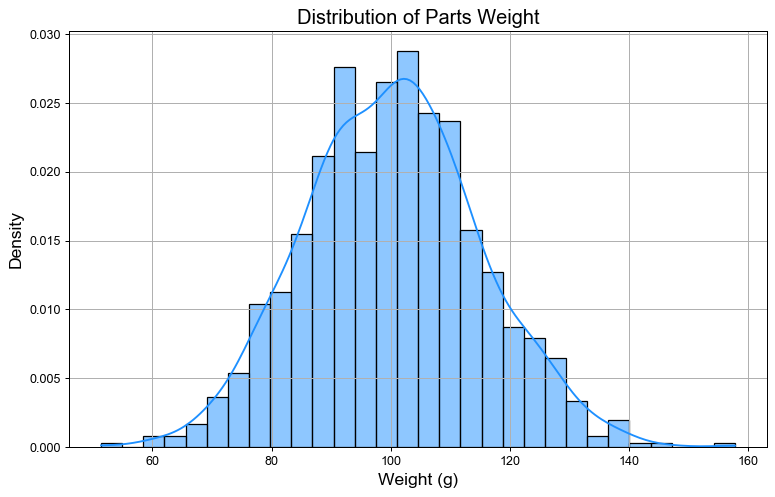

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kstest, norm

# 设置随机数种子，确保结果可复现
np.random.seed(42)

# 生成符合正态分布的数据（零件重量数据，均值为100克，标准差为15克，数据量为1000）
data = np.random.normal(loc=100, scale=15, size=1000)

# 可视化数据的分布
plt.figure(figsize=(10, 6))
sns.histplot(data, kde=True, color='dodgerblue', bins=30, stat='density')
plt.title('Distribution of Parts Weight', fontsize=16)
plt.xlabel('Weight (g)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_018.png)

- 我们生成了一个正态分布的模拟数据集，均值为100克，标准差为15克，样本容量为1000。
- 使用`seaborn`的`histplot`进行数据分布的可视化，同时叠加了核密度估计（KDE）曲线，方便观察数据的分布形态。

### 2. 使用Shapiro-Wilk检验和Kolmogorov-Smirnov检验进行正态性检验

#### Shapiro-Wilk检验：

Shapiro-Wilk检验用于判断数据是否符合正态分布。其零假设是数据符合正态分布，备择假设是数据不符合正态分布。

In [3]:
# Shapiro-Wilk 正态性检验
shapiro_stat, shapiro_p_value = shapiro(data)

print(f"Shapiro-Wilk Test Statistic: {shapiro_stat}")
print(f"Shapiro-Wilk P-Value: {shapiro_p_value}")

# 结果解读
if shapiro_p_value > 0.05:
    print("数据符合正态分布（接受零假设）")
else:
    print("数据不符合正态分布（拒绝零假设）")

Shapiro-Wilk Test Statistic: 0.9986092190571162
Shapiro-Wilk P-Value: 0.6272578290246378
数据符合正态分布（接受零假设）


#### Kolmogorov-Smirnov检验：

Kolmogorov-Smirnov（K-S）检验是一种基于经验分布函数与理论分布函数（在此为正态分布）之间的差异来检验正态性的方法。

In [4]:
# Kolmogorov-Smirnov 正态性检验
ks_stat, ks_p_value = kstest(data, 'norm', args=(np.mean(data), np.std(data)))

print(f"Kolmogorov-Smirnov Test Statistic: {ks_stat}")
print(f"Kolmogorov-Smirnov P-Value: {ks_p_value}")

# 结果解读
if ks_p_value > 0.05:
    print("数据符合正态分布（接受零假设）")
else:
    print("数据不符合正态分布（拒绝零假设）")

Kolmogorov-Smirnov Test Statistic: 0.021479979161405482
Kolmogorov-Smirnov P-Value: 0.7369569123250448
数据符合正态分布（接受零假设）


- **Shapiro-Wilk检验**：检验返回一个统计量和p值。如果p值大于显著性水平（通常为0.05），则可以接受数据符合正态分布的假设。
- **Kolmogorov-Smirnov检验**：同样返回统计量和p值。它是通过比较样本的经验分布与理论分布之间的最大差异来进行检验。

### 3. 绘制QQ图和分布图

QQ图的原理是将样本数据的分位数与标准正态分布的分位数进行比较，如果数据符合正态分布，则图中的点应大致沿着一条直线分布。

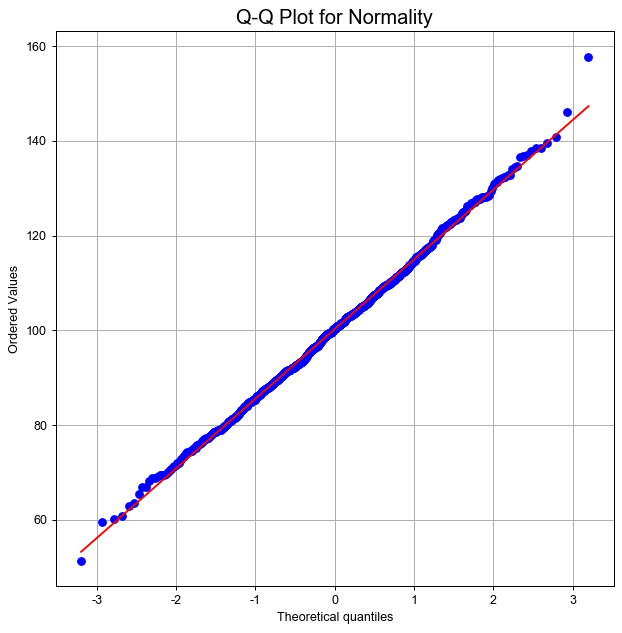

In [5]:
import scipy.stats as stats

# 绘制QQ图
plt.figure(figsize=(8, 8))
stats.probplot(data, dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality', fontsize=16)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_019.png)

- QQ图中的点应该大致沿着一条直线分布。如果点偏离直线很多，说明数据不符合正态分布。

### 4. 做出结论并分析

结合Shapiro-Wilk检验、Kolmogorov-Smirnov检验和QQ图的结果，我们可以做出结论。

#### 假设检验总结：

- 如果Shapiro-Wilk检验的p值大于0.05，说明数据符合正态分布。
- 如果Kolmogorov-Smirnov检验的p值大于0.05，说明数据符合正态分布。
- 通过QQ图，我们可以直观地判断数据是否符合正态分布。

#### 优化与改进：

在一些实际应用中，数据可能出现轻微的偏态或峰态，而Shapiro-Wilk检验和K-S检验对偏态和峰态非常敏感。如果数据的偏态不明显，但仍然不完全符合正态分布，我们可以通过数据转换（如对数变换、平方根变换等）来改善数据的正态性。

例如，假设我们发现数据稍微右偏，我们可以尝试对数据进行对数变换：

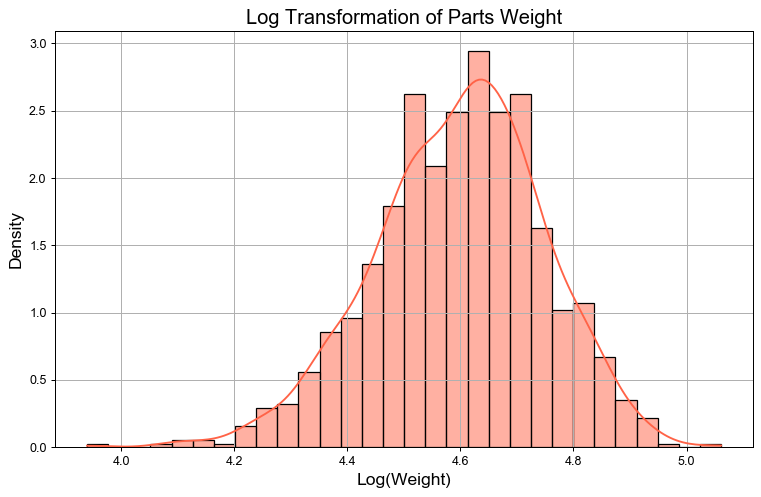

Log-transformed Shapiro-Wilk P-Value: 7.636905068962214e-05
Log-transformed Kolmogorov-Smirnov P-Value: 0.10008269785810553


In [6]:
# 对数据进行对数变换
log_data = np.log(data)

# 可视化对数变换后的数据分布
plt.figure(figsize=(10, 6))
sns.histplot(log_data, kde=True, color='tomato', bins=30, stat='density')
plt.title('Log Transformation of Parts Weight', fontsize=16)
plt.xlabel('Log(Weight)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True)
plt.show()

# 重新进行正态性检验
shapiro_stat, shapiro_p_value = shapiro(log_data)
ks_stat, ks_p_value = kstest(log_data, 'norm', args=(np.mean(log_data), np.std(log_data)))

print(f"Log-transformed Shapiro-Wilk P-Value: {shapiro_p_value}")
print(f"Log-transformed Kolmogorov-Smirnov P-Value: {ks_p_value}")

![原文参考图，当前结果见代码输出](attachments/img_020.png)

- 通过对数变换，数据的偏态可能会得到改善，从而提高其符合正态分布的程度。
- 进行对数变换后的数据再次进行Shapiro-Wilk检验和Kolmogorov-Smirnov检验，可能会得到更高的p值，从而支持数据符合正态分布的结论。

### 5. 优化与改进

#### 如何改进算法：

- **数据预处理**：针对数据的偏态或离群值进行预处理，确保数据更加接近正态分布。
- **更多的检验方法**：除了Shapiro-Wilk检验和K-S检验，还可以使用Anderson-Darling检验等其他方法进行正态性检验。
- **算法选择**：对于非常大的数据集，Shapiro-Wilk检验可能变得计算开销较大，可以选择适合大数据集的检验方法，如Anderson-Darling检验。

## 模型分析

### 优缺点

**优点**：

1. **直观和易于理解**：正态性检验通过Shapiro-Wilk和Kolmogorov-Smirnov检验等方法，基于样本的统计量与正态分布的理论分布进行比较，使得检验过程透明且易于解释。特别是Shapiro-Wilk检验，广泛应用于实际中，是简单且计算高效的正态性检验方法。
2. **广泛适用**：对于小样本（尤其是样本量小于50），Shapiro-Wilk检验是一种非常有效的工具，并且它在多种领域中都有较高的应用频率。Kolmogorov-Smirnov检验同样可以作为补充的选择，特别是当数据量较大时。
3. **强大的可视化支持**：QQ图等可视化手段是验证数据是否符合正态分布的直观工具。通过这种方式，能够帮助我们快速识别出数据分布的特征，例如偏态或峰态情况，从而有助于进一步选择合适的检验方法。
4. **适用于大部分传统统计分析方法**：很多统计方法（例如t检验、ANOVA分析）都假设数据符合正态分布。通过进行正态性检验，可以确保这些假设得以满足，从而使得后续分析结果更加可靠。

**缺点**：

1. **对大样本不敏感**：当样本量非常大时（比如样本量大于1000），Shapiro-Wilk和Kolmogorov-Smirnov检验可能会检测到极小的偏差，而这些偏差可能并不足以影响后续分析的结果。大样本情况下，这些检验过于敏感，可能导致错误的拒绝正态性的结论。
2. **假设过于严格**：正态性检验通常依赖于数据非常接近正态分布。如果数据稍微偏离正态分布（例如有轻微的偏态或峰态），它们可能会判断数据不符合正态分布，尽管这些偏差对实际分析并没有显著影响。
3. **不适用于非常重尾的数据**：对于那些有非常重尾或极端离群值的数据，传统的正态性检验方法可能无法准确捕捉到数据的分布特征。尤其在金融数据或自然灾害等极端事件频发的领域，正态性检验可能会失效。
4. **计算负担**：对于极大的数据集，Shapiro-Wilk检验的计算开销相对较大，尽管它是有效的，但在实践中，对于大规模数据的应用，可能会导致计算资源和时间的浪费。

#### 适用场景：

- 当样本数据量适中（通常少于500个样本）且数据呈现出接近正态分布的形态时，正态性检验模型是优选。
- 当我们需要确保后续的统计分析（如t检验、ANOVA）可以有效地应用时，正态性检验提供了必要的前提检查。

#### 不适用场景：

- 在样本量非常大（大于1000个样本）且数据轻微偏离正态分布的情况下，可能会因为正态性检验的过度敏感而错误地拒绝零假设。
- 如果数据有明显的极端值或重尾分布（例如金融数据），传统的正态性检验方法可能会产生误导性结果，此时需要考虑其他方法。

### 与相似算法的对比

在正态性检验中，除了Shapiro-Wilk检验和Kolmogorov-Smirnov检验，还有其他一些常见的检验方法。

| **检验方法** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|
| **Shapiro-Wilk检验** | 1. 对小样本有效，且计算效率较高。  <br/>2. 精度较高，能很好地捕捉数据是否偏离正态分布。 | 1. 对大样本过于敏感，可能出现错误拒绝零假设的情况。  <br/>2. 对重尾数据不敏感。 | 适用于样本量较小的情况，尤其是数据接近正态分布时。 |
| **Kolmogorov-Smirnov检验** | 1. 对大样本适用，计算较为高效。  <br/>2. 可以处理任何分布的正态性检验。 | 1. 对数据的偏态和峰态较为敏感。  <br/>2. 结果可能受到样本大小的影响。 | 适用于大样本数据，尤其是需要检验样本分布是否与理论分布相符时。 |
| **Anderson-Darling检验** | 1. 对数据偏态和峰态较为敏感，能更好地捕捉到偏离正态分布的特征。 | 1. 相较Shapiro-Wilk检验，计算量更大。  <br/>2. 适用范围较为局限，主要针对正态性检验。 | 适用于轻微偏态或峰态的数据集，能够捕捉到更细微的正态性偏差。 |
| **Lilliefors检验** | 1. 针对小样本的数据正态性检验，计算较为简单。  <br/>2. 适用于少量样本数据的情境。 | 1. 适用范围相对较窄，更多用于检验小样本数据的正态性。 | 适用于少量样本的数据，特别是当数据量非常小且不能使用Shapiro-Wilk时。 |

### 结论与讨论

#### 优选算法：

- 当**数据量较小**（通常小于500个数据点），且数据**大致符合正态分布**时，**Shapiro-Wilk检验**是优选的算法。它具有较高的精度和计算效率，非常适合常见的小样本情况。
- 如果数据量较大（超过1000个数据点），可以考虑使用**Kolmogorov-Smirnov检验**，该方法计算高效且能处理大样本。
- 对于数据中出现了**轻微的偏态或峰态**，可以考虑使用**Anderson-Darling检验**，它对偏态和峰态更加敏感，能够更好地捕捉数据的非正态性。

#### 考虑其他算法的情境：

- **大样本情况下**（尤其是样本大于1000），正态性检验可能由于数据的小偏差而错误地拒绝零假设，此时可以考虑**非参数检验**（如Mann-Whitney U检验）来避免过度依赖正态性假设。
- 对于具有**极端离群值**或**重尾分布**的情况（如金融数据、环境数据等），传统的正态性检验可能无法准确判断数据的分布。此时可以考虑使用**非参数方法**或**重尾分布模型**（如学生t分布或分位数回归）来更好地处理这些数据。
- 如果数据的**分布偏离正态分布非常严重**，且我们不打算进行传统的正态假设检验，可以选择使用**数据变换**（如对数变换或Box-Cox变换）来将数据转换为正态分布，或者选择其他基于模型的方法（如高斯混合模型）来处理数据。

总结而言，**正态性检验**作为一种常见的统计方法，适用于多种场景，尤其是在小样本情况下，但它的过于严格的假设和对大样本过度敏感的问题需要在实际应用中谨慎考虑。在数据量较大、极端离群值多或者分布有重尾的情况下，其他方法可能更为适用。